In [1]:
print("test")

test


In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Literal, List, Sequence, Annotated

In [3]:
class EmployeeState(TypedDict):
    name : str
    salary : float
    age : int
    decision : Literal["std_hr", "forced_hr",]
    result : str


In [4]:
def analyze_employee(state: EmployeeState) -> EmployeeState:
    """ """
    age = state["age"]
    salary = state["salary"]
    if age > 50 and salary < 50000:
        state["decision"] = "std_hr"
    else:
        state["decision"] = "forced_hr"
    print(f"le dossier de {state['name']} a été analysé, décision : {state['decision']}")
    return state

In [5]:
def standard_hr_process(state: EmployeeState):
    """ """
    state["result"] = f"le dossier de {state['name']} a été traité par le processus standard, résultat : {state['decision']}"
    print("*"*80)
    print(f"le dossier de {state['name']} a été traité par le processus standard, résultat : {state['decision']}")
    print(f"name {state['name']} salary : {state['salary']}, age: {state['age']}")

    print("*"*80)
    return state

In [6]:
def forced_hr_process(state: EmployeeState):
    """ """
    state["result"] = f"le dossier de {state['name']} a été traité par le processus forcé"
    print("*"*80)
    print(f"le dossier de {state['name']} a été traité par le processus forcé")
    print(f"name {state['name']} salary : {state['salary']}, age: {state['age']}")

    print("*"*80)
    return state

In [8]:
def router(state: EmployeeState):
    return state["decision"]

In [9]:
workflow = StateGraph(EmployeeState)
workflow.add_node("Analyze_node", analyze_employee)
workflow.add_node("standard_hr_node", standard_hr_process)
workflow.add_node("forced_hr_node", forced_hr_process)
workflow.add_edge(START, "Analyze_node")
workflow.add_conditional_edges(
    "Analyze_node",
     router,
     {
         "std_hr":"standard_hr_node",
         "forced_hr":"forced_hr_node"
     }
      )
workflow.add_edge("standard_hr_node", END)
workflow.add_edge("forced_hr_node", END)

graph = workflow.compile()

In [10]:
from IPython.display import Image


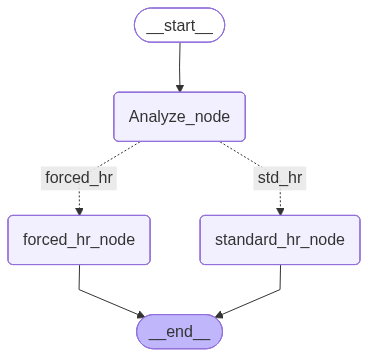

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
result = graph.invoke({
    "name":"Rahma", "age":65, "salary":20000
})

le dossier de Rahma a été analysé, décision : std_hr
********************************************************************************
le dossier de Rahma a été traité par le processus standard, résultat : std_hr
name Rahma salary : 20000, age: 65
********************************************************************************


In [14]:
print(result)

{'name': 'Mohamed', 'salary': 30000, 'age': 40, 'decision': 'forced_hr', 'result': 'le dossier de Mohamed a été traité par le processus forcé'}


In [13]:
result = graph.invoke({
    "name":"Mohamed", "age":40, "salary":30000
})

le dossier de Mohamed a été analysé, décision : forced_hr
********************************************************************************
le dossier de Mohamed a été traité par le processus forcé
name Mohamed salary : 30000, age: 40
********************************************************************************


In [66]:
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.messages import BaseMessage, AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from dotenv.ipython import load_dotenv
import os
from langgraph.checkpoint.memory import InMemorySaver


In [42]:
load_dotenv(override=True)

True

In [43]:
@tool
def add(a:float, b:float):
    """ 
    Add two numbers a and b .
    """
    print(f"Adding{a} to {b}")
    return a + b


@tool
def multiply(a:float, b:float):
    """ 
    Multiply two numbers a and b .
    """
    print(f"multiplying{a} by {b}")
    return a * b

@tool
def devide(a:float, b:float):
    """ 
    Dividing two numbers a and b .
    """
    print(f"Dividing{a} by {b}")
    return a / b


tools = [add, multiply, devide]

In [44]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage], add_messages]
    
    

In [60]:
llm = ChatOpenAI(model="gpt-4o", temperature=1)
llm_with_tools = llm.bind_tools(tools)

In [61]:
def assistant(state: AgentState) -> AgentState:
    """ """
    response = llm_with_tools.invoke(state['messages'])
    print("*"*50)
    print("LLM invoke")
    return {"messages": [response]}

In [53]:
def should_continue(state: AgentState) -> bool:
    """ """
    last_message = state['messages'][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"
        

In [67]:
workflow = StateGraph(AgentState)
workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.set_entry_point("assistant")
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "end":END,
        "continue" : "tools"
    }
)
workflow.add_edge("tools", "assistant")
memory = InMemorySaver()
graph = workflow.compile(checkpointer=memory) 

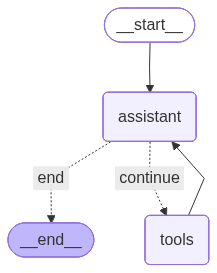

In [63]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [64]:
resp = graph.invoke({
    "messages":[HumanMessage("ajoute 5 à 20 et puis multiplie le resultat par 20 et puis donne moi un proverbe en arabe et sa traduction")]

})

**************************************************
LLM invoke
Adding5.0 to 20.0
**************************************************
LLM invoke
multiplying25.0 by 20.0
**************************************************
LLM invoke


In [65]:
print(resp['messages'][-1].content)

Le résultat de l'opération est 500.

Voici un proverbe en arabe:
"من جد وجد، ومن زرع حصد."

Traduction:
"Qui se donne de la peine, trouve. Celui qui sème, récolte."
